# 1. Importación

Carga de las librerías necesarias y del dataset original en crudo.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/raw/listings.csv")
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,18674,Huge flat for 8 people close to Sagrada Familia,71615.0,1.462508e+18,Maria Y Mireia Barcelona4Seasons,Eixample,la Sagrada Família,41.405560,2.17262,Entire home/apt,409.0,1.0,59,2026-05-28,0.37,20.0,123,9,Spain - National registration number<br />ESFC...
1,23197,CCIB Forum· Large Balcony · 5 min walk to CCIB,90417.0,1.462509e+18,Marnie,Sant Martí,el Besòs i el Maresme,41.412432,2.21975,Entire home/apt,388.0,2.0,99,2026-06-07,0.53,1.0,239,11,Spain - National registration number<br />ESFC...
2,34981,VIDRE HOME PLAZA REAL on LAS RAMBLAS,73163.0,1.462508e+18,Andres,Ciutat Vella,el Barri Gòtic,41.379780,2.17623,Entire home/apt,397.0,1.0,304,2026-05-26,1.59,2.0,329,37,Spain - National registration number<br />ESFC...
3,36763,In front of the beach,158596.0,1.462511e+18,Ester,Ciutat Vella,la Barceloneta,41.380370,2.19272,Private room,43.0,31.0,108,2023-12-13,0.60,1.0,38,0,NaN
4,40983,Architect's Loft near Gaudí & Passeig de Gràcia,177617.0,1.462512e+18,Joaquin,Eixample,la Dreta de l'Eixample,41.396310,2.16832,Entire home/apt,226.0,1.0,450,2026-06-19,2.46,5.0,289,56,Barcelona - Regional registration number<br />...


## 2. Básico

Primer vistazo a la estructura del dataset: dimensiones, tipos de datos y estadísticos descriptivos generales.

In [3]:
print(df.shape)
print(df.dtypes)

(15406, 19)
id                                  int64
name                               object
host_id                           float64
host_profile_id                   float64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                    int64
number_of_reviews_ltm               int64
license                            object
dtype: object


In [4]:
df.describe()

,id,host_id,host_profile_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,1.540600e+04,1.529300e+04,1.521200e+04,15406.000000,15406.000000,13465.000000,15405.000000,15406.000000,11822.000000,15293.000000,15406.000000,15406.000000
mean,7.143752e+17,1.029976e+16,1.470058e+18,41.392197,2.166934,240.713182,13.963129,67.085746,1.566824,73.839992,212.950149,13.243671
std,6.568077e+17,1.316853e+17,2.706495e+16,0.013529,0.017682,338.419900,21.310367,133.002928,2.348756,146.257623,118.906959,29.352521
min,1.867400e+04,1.070400e+04,1.462507e+18,41.351783,2.092414,4.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,3.253732e+07,9.469830e+06,1.462659e+18,41.381480,2.156595,90.000000,1.000000,1.000000,0.220000,2.000000,117.000000,0.000000
50%,8.102725e+17,9.633738e+07,1.465487e+18,41.390475,2.167680,179.000000,2.000000,9.000000,0.960000,10.000000,241.000000,2.000000
75%,1.353469e+18,3.463675e+08,1.469532e+18,41.401200,2.177460,286.000000,31.000000,76.000000,2.360000,43.000000,319.000000,20.000000
max,1.714532e+18,1.713762e+18,1.714078e+18,41.462243,2.221390,10542.000000,900.000000,2740.000000,100.580000,588.000000,365.000000,1276.000000


## 3. Corrección de tipos

Ajustar columnas con un tipo de dato mal inferido (p. ej. `last_review` como texto en vez de fecha, o IDs como float) para poder trabajar con ellas correctamente.

In [5]:
df["last_review"] = pd.to_datetime(df["last_review"])
df["last_review"].dtype

dtype('<M8[ns]')

In [6]:
# host_id y host_profile_id son identificadores (enteros), pero pandas los infirió
# como float64 porque contienen nulos. Int64 (con mayúscula) admite enteros + NaN.
df["host_id"] = df["host_id"].astype("Int64")
df["host_profile_id"] = df["host_profile_id"].astype("Int64")
df[["host_id", "host_profile_id"]].dtypes

host_id            Int64
host_profile_id    Int64
dtype: object

In [7]:
df.dtypes

id                                         int64
name                                      object
host_id                                    Int64
host_profile_id                            Int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                    float64
minimum_nights                           float64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count           float64
availability_365                           int64
number_of_reviews_ltm                      int64
license                                   object
dtype: object

## 4. Nulos

Identificar qué columnas tienen valores nulos, en qué cantidad/proporción, y decidir cómo tratarlos (imputar, crear flag o descartar filas).

In [8]:
df.isnull().sum().sort_values(ascending=False)

reviews_per_month                 3584
last_review                       3584
license                           3156
price                             1941
host_name                          200
host_profile_id                    194
host_id                            113
calculated_host_listings_count     113
minimum_nights                       1
number_of_reviews                    0
number_of_reviews_ltm                0
availability_365                     0
id                                   0
name                                 0
longitude                            0
latitude                             0
neighbourhood                        0
neighbourhood_group                  0
room_type                            0
dtype: int64

In [9]:
(df.isnull().sum() / df.shape[0] * 100).round(2).sort_values(ascending=False)

reviews_per_month                 23.26
last_review                       23.26
license                           20.49
price                             12.60
host_name                          1.30
host_profile_id                    1.26
host_id                            0.73
calculated_host_listings_count     0.73
minimum_nights                     0.01
number_of_reviews                  0.00
number_of_reviews_ltm              0.00
availability_365                   0.00
id                                 0.00
name                               0.00
longitude                          0.00
latitude                           0.00
neighbourhood                      0.00
neighbourhood_group                0.00
room_type                          0.00
dtype: float64

### 4.1 Estrategia de tratamiento

Cada grupo de columnas con nulos tiene una causa distinta, así que se trata de forma separada en vez de aplicar una regla genérica (p. ej. `fillna(0)` a todo):

- `reviews_per_month` / `last_review`: alojamientos sin reviews.
- `license`: alojamientos sin licencia registrada.
- `price`: variable económica clave, no se imputa a ciegas.
- `host_name`, `host_id`, `host_profile_id`, `calculated_host_listings_count`, `minimum_nights`: bajo volumen de nulos, se descartan las filas afectadas.

#### `reviews_per_month` y `last_review`

Hipótesis: estos campos son nulos porque el alojamiento nunca ha recibido reviews (`number_of_reviews == 0`), no porque falte el dato. Se comprueba antes de decidir el tratamiento.

In [10]:
# Si la hipótesis es correcta, el único valor de number_of_reviews en estas filas debe ser 0
df.loc[df["reviews_per_month"].isnull(), "number_of_reviews"].unique()

array([0])

Se confirma: los nulos de `reviews_per_month` coinciden exactamente con `number_of_reviews == 0`. Por tanto:

- `reviews_per_month` se imputa a `0`, ya que 0 reviews/mes es el valor real y coherente para un alojamiento sin reviews.
- `last_review` se deja como `NaT`: no existe una fecha real que asignar, y el propio nulo ya es informativo ("nunca ha tenido reviews"), así que inventar una fecha sería peor que dejarlo vacío.

In [11]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

Es un campo de texto libre con el número de registro turístico. Un nulo aquí probablemente significa que el alojamiento no tiene licencia registrada, no que falte el dato por error. En vez de imputar un valor inventado, se marca explícitamente como categoría `"Sin licencia"` para poder tratarla como variable categórica en el análisis (p. ej. comparar precios con/sin licencia).

In [12]:
df["license"] = df["license"].fillna("Sin licencia")

#### `price`

`price` es la variable económica clave del dataset (posible objetivo de modelado más adelante), por lo que no se imputa: cualquier valor inventado (media, mediana, etc.) sesgaría tanto el EDA como un futuro modelo. Con un 12.6% de nulos, se opta por eliminar esas filas en vez de conservarlas con un valor artificial.

In [13]:
df = df.dropna(subset=["price"])
df.shape

(13465, 19)

#### `host_name`, `host_id`, `host_profile_id`, `calculated_host_listings_count` y `minimum_nights`

Son columnas identificativas del host (más una única fila con `minimum_nights` nulo), todas con muy baja proporción de nulos (≤1.3%). Al tratarse de identificadores, no tiene sentido imputarlos (no existe un "host medio"), así que se descartan directamente las filas afectadas: el volumen es pequeño y no compensa el riesgo de introducir datos falsos.

In [14]:
df = df.dropna(subset=[
    "host_name",
    "host_id",
    "host_profile_id",
    "calculated_host_listings_count",
    "minimum_nights",
])
df.shape

(13276, 19)

#### Comprobación final

Verificamos los nulos restantes por columna. Solo deben quedar en `last_review`: es el nulo que se dejó deliberadamente para los alojamientos sin reviews, no un descuido.

In [15]:
df.isnull().sum().sort_values(ascending=False)

last_review                       2936
id                                   0
price                                0
number_of_reviews_ltm                0
availability_365                     0
calculated_host_listings_count       0
reviews_per_month                    0
number_of_reviews                    0
minimum_nights                       0
room_type                            0
name                                 0
longitude                            0
latitude                             0
neighbourhood                        0
neighbourhood_group                  0
host_name                            0
host_profile_id                      0
host_id                              0
license                              0
dtype: int64

## 5. Duplicados

Comprobar si existen filas duplicadas en el dataset y eliminarlas si procede.

In [16]:
df.duplicated().sum()  # no hay duplicados

np.int64(0)

In [17]:
df = df.drop_duplicates() # por si acaso

### 5.1 Duplicados por `id`

`id` es el identificador único de cada anuncio en Airbnb: no debería repetirse nunca. Comprobarlo aparte de la fila completa es más estricto, porque dos filas podrían tener el mismo `id` con algún otro campo distinto (p. ej. actualizado entre extracciones) y no saltar como duplicado de fila completa.

In [18]:
df["id"].duplicated().sum()

np.int64(0)

### 5.2 Duplicados lógicos (mismo alojamiento, `id` distinto)

Hipótesis: un mismo alojamiento físico podría estar publicado varias veces con `id` distinto (p. ej. varios anuncios del mismo piso por el mismo host). Se aproxima buscando filas que comparten `name`, `host_name`, `latitude` y `longitude` a la vez, algo muy improbable por azar. Es solo diagnóstico: aún no se decide si se eliminan o se dejan.

In [19]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
logical_dup_mask = df.duplicated(subset=dup_cols, keep=False)

print("filas implicadas:", logical_dup_mask.sum())
print("grupos de alojamiento distintos:", df[logical_dup_mask].groupby(dup_cols).ngroups)

filas implicadas: 222
grupos de alojamiento distintos: 83


In [20]:
# Muestra de un par de grupos para inspeccionar qué cambia entre anuncios "duplicados"
df[logical_dup_mask].sort_values(dup_cols)[
    ["id", "name", "host_name", "room_type", "price", "minimum_nights"]
].head(15)

,id,name,host_name,room_type,price,minimum_nights
11402,1338934630633352572,4 bedroom apartment with 2 bathrooms,Rosa,Entire home/apt,260.0,1.0
11404,1338934657490458167,4 bedroom apartment with 2 bathrooms,Rosa,Entire home/apt,260.0,1.0
11406,1338934678039515276,4 bedroom apartment with 2 bathrooms,Rosa,Entire home/apt,260.0,1.0
11408,1338934697682776010,4 bedroom apartment with 2 bathrooms,Rosa,Entire home/apt,260.0,1.0
11410,1338934741854061619,4 bedroom apartment with 2 bathrooms,Rosa,Entire home/apt,260.0,1.0
11403,1338934645732846973,4 bedroom family apartment with 3 bathrooms,Rosa,Entire home/apt,230.0,1.0
11405,1338934666210370276,4 bedroom family apartment with 3 bathrooms,Rosa,Entire home/apt,230.0,1.0
11407,1338934687386652193,4 bedroom family apartment with 3 bathrooms,Rosa,Entire home/apt,230.0,1.0
11409,1338934721622095980,4 bedroom family apartment with 3 bathrooms,Rosa,Entire home/apt,230.0,1.0
12700,1460861820560243476,Alessandra Central Ramblas.,Silvia De Lourdes,Entire home/apt,147.0,25.0


### 5.3 Conclusión y tratamiento

Al revisar el resto de columnas dentro de cada grupo (número de reviews, disponibilidad, licencia...) se ve que la mayoría de estos 83 grupos son anuncios legítimamente distintos: mismo edificio y mismo host, pero cada fila tiene su propio número de licencia y su propio historial de reservas (distinto `number_of_reviews`, `availability_365`, etc.) — son unidades diferentes, no un error de datos, así que se conservan.

Dentro de esos grupos hay un subconjunto de filas que son idénticas en **absolutamente todas** las columnas salvo `id`: no aportan ninguna información adicional, son el mismo anuncio repetido con un id distinto (probablemente un artefacto de la extracción). Solo esas se consideran duplicados reales y se eliminan, quedándonos con la primera aparición de cada una.

In [21]:
cols_except_id = [c for c in df.columns if c != "id"]
is_real_duplicate = df.duplicated(subset=cols_except_id, keep="first")

print("filas idénticas en todo salvo id:", is_real_duplicate.sum())

filas idénticas en todo salvo id: 38


In [22]:
df = df[~is_real_duplicate].copy()
df.shape

(13238, 19)

## 6. Variables Categóricas

Análisis univariante de las variables categóricas: cardinalidad y distribución de frecuencias de cada una.

In [23]:
cat = df.select_dtypes(include="object").columns
print(cat)

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'license'],
      dtype='object')


In [24]:
for i in cat:
    num = df[i].nunique()
    print(f"{i}, {num}")

name, 12770
host_name, 2047
neighbourhood_group, 10
neighbourhood, 69
room_type, 4
license, 9786


### 6.1 Cardinalidad: identificadores vs. categóricas reales

`name`, `host_name` y `license` tienen una cardinalidad casi tan alta como el número de filas (12770, 2047 y 9786 frente a 13238 filas): son casi identificadores de texto libre, no categorías con pocas clases, así que no tiene sentido analizarlas con `value_counts()` valor a valor. `neighbourhood_group`, `neighbourhood` y `room_type` sí son categóricas genuinas (10, 69 y 4 clases) y se analizan su distribución de frecuencias más abajo.

#### `license`: ¿qué proporción de anuncios no tiene licencia?

Ahora que los nulos se imputaron como la categoría `"Sin licencia"` (ver sección 4), sí tiene sentido mirar qué peso tiene esa categoría frente al resto, aunque cada licencia real sea casi única.

In [25]:
(df["license"] == "Sin licencia").mean() * 100

np.float64(13.415923855567305)

Se convierte esa señal en un flag binario en vez de mantener el texto completo (que es casi único por fila y no aporta como categórica).

In [26]:
df["has_license"] = df["license"] != "Sin licencia"

<Axes: xlabel='has_license', ylabel='count'>

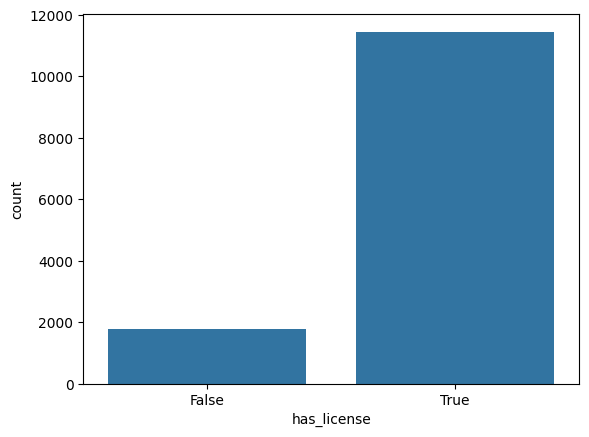

In [27]:
sns.countplot(data=df, x="has_license")

#### `host_name`: concentración de anuncios por host

Aunque `host_name` tiene alta cardinalidad en general, es de esperar que unos pocos hosts (empresas de gestión de apartamentos) concentren muchos anuncios cada uno. Se revisan los 10 con más anuncios.

In [28]:
df["host_name"].value_counts().head(10)

host_name
Ukio                      537
Acomodis Apartments       444
Silvia De Lourdes         320
Sweett                    293
AB Apartment Barcelona    241
Badi Plus                 206
Stay Unique               156
Room Housing              136
BeBarceloner              124
Habitat Apartments        118
Name: count, dtype: int64

<Axes: ylabel='host_name'>

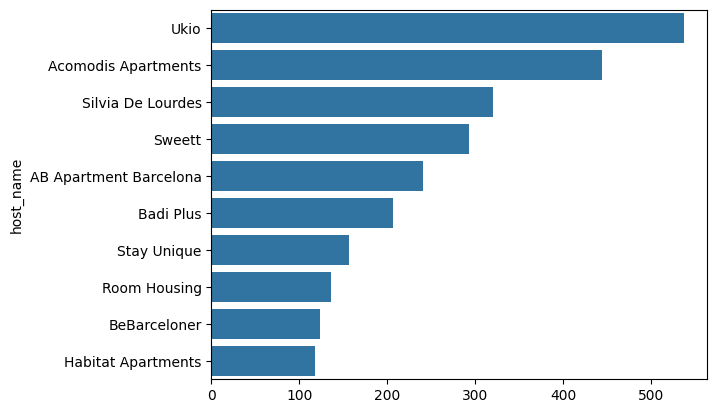

In [29]:
top_hosts = df["host_name"].value_counts().head(10)
sns.barplot(x=top_hosts.values, y=top_hosts.index)

No se transforma `name` ni `host_name` en esta fase: ambas son cuasi-identificadores de texto libre y usarlas en bruto como categóricas dispararía la dimensionalidad. Cualquier señal útil (palabras clave del título, o un flag `is_professional_host` derivado de `calculated_host_listings_count`) se deja para `02A_fe_listings.ipynb`.

### 6.2 Categóricas de baja cardinalidad

Para `neighbourhood_group`, `neighbourhood` y `room_type` sí tiene sentido analizar la distribución completa de frecuencias.

In [30]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Eixample               5158
Ciutat Vella           2763
Sants-Montjuïc         1276
Sant Martí             1223
Gràcia                 1192
Sarrià-Sant Gervasi     753
Horta-Guinardó          289
Les Corts               262
Sant Andreu             180
Nou Barris              142
Name: count, dtype: int64

Los anuncios se concentran fuertemente en dos barrios: `Eixample` y `Ciutat Vella` suman por sí solos cerca del 60% del total, y el resto de `neighbourhood_group` va perdiendo peso rápido (los tres últimos apenas superan el 1-2% cada uno).

In [31]:
df["neighbourhood"].value_counts().sort_values(ascending=False)

neighbourhood
la Dreta de l'Eixample                   1916
el Raval                                  866
la Vila de Gràcia                         821
la Sagrada Família                        803
Sant Pere, Santa Caterina i la Ribera     790
                                         ... 
el Bon Pastor                               3
Montbau                                     2
la Trinitat Vella                           2
Torre Baró                                  1
Ciutat Meridiana                            1
Name: count, Length: 69, dtype: int64

`neighbourhood` tiene 69 categorías, pero muchas apenas tienen anuncios. Se cuenta cuántos barrios quedan por debajo de un umbral bajo (10 anuncios), como referencia por si más adelante interesa agruparlos en una categoría "Otros" para reducir cardinalidad.

In [32]:
(df["neighbourhood"].value_counts() < 10).sum()

np.int64(12)

Se agrupan esos 12 barrios minoritarios en una categoría `"Otros"`, creando `neighbourhood_grouped`, para no arrastrar clases con muestra insuficiente al modelar (p. ej. al hacer un split train/test). Se conserva la columna original `neighbourhood` por si se necesita el detalle más adelante.

In [33]:
rare_neighbourhoods = df["neighbourhood"].value_counts()
rare_neighbourhoods = rare_neighbourhoods[rare_neighbourhoods < 10].index

df["neighbourhood_grouped"] = df["neighbourhood"].where(
    ~df["neighbourhood"].isin(rare_neighbourhoods), "Otros"
)
df["neighbourhood_grouped"].nunique()

58

<Axes: xlabel='count', ylabel='neighbourhood_group'>

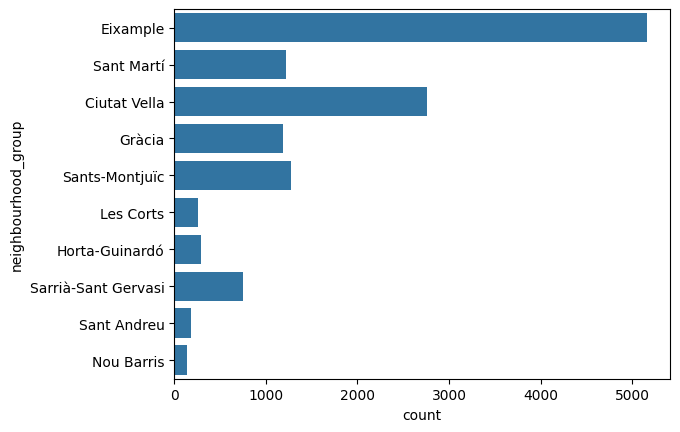

In [34]:
sns.countplot(data=df, y="neighbourhood_group")

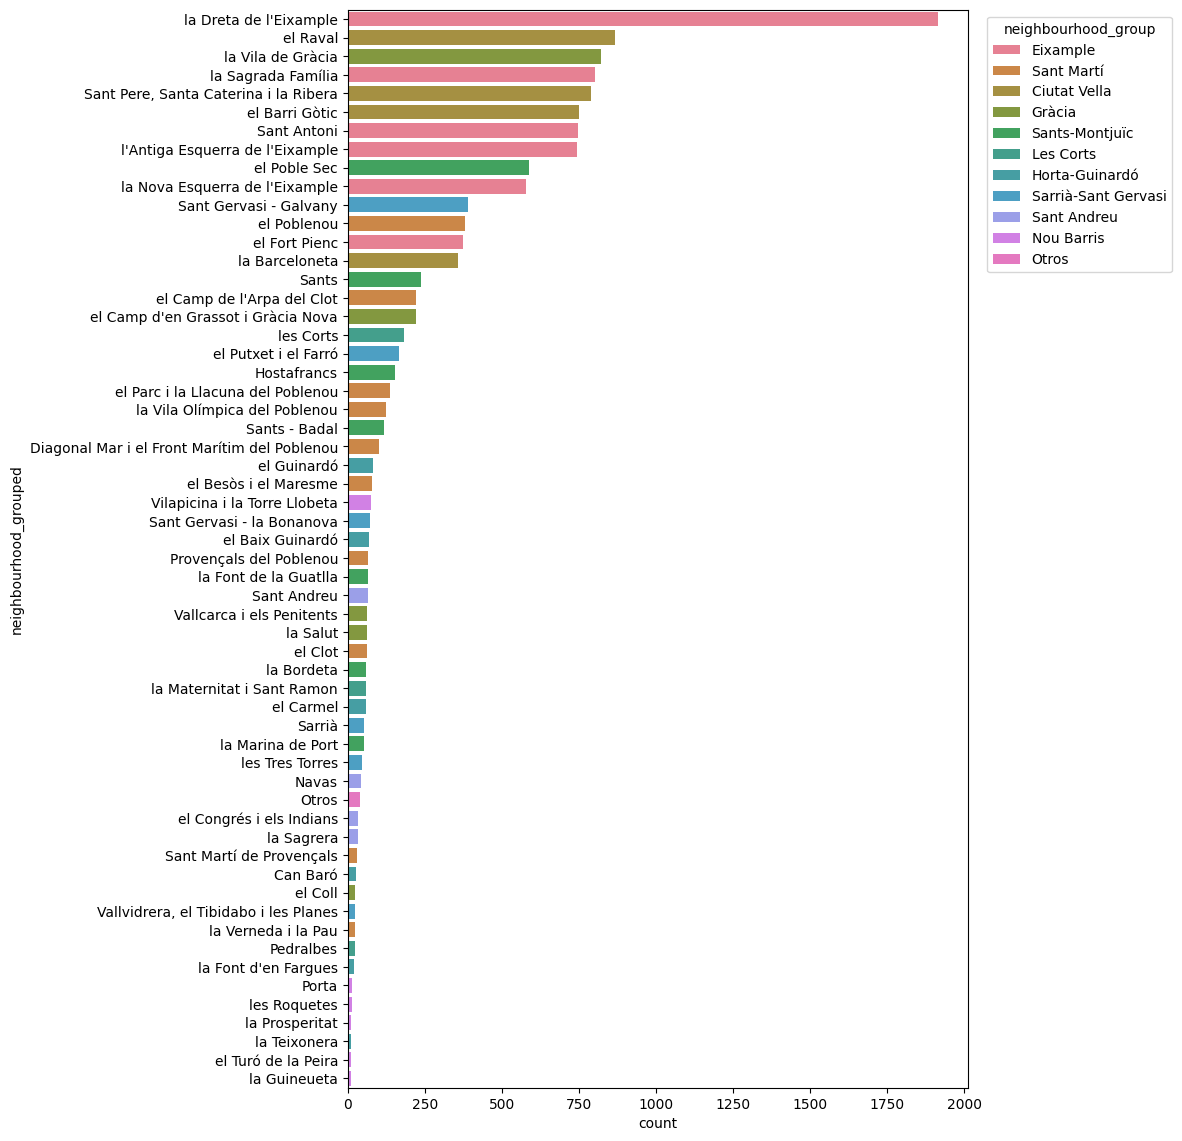

In [35]:
# Se colorea por neighbourhood_group (el distrito al que pertenece cada barrio).
# "Otros" agrupa barrios de varios distritos distintos, así que se le asigna su propio color en vez de heredar uno.
neighbourhood_to_group = (
    df.loc[df["neighbourhood_grouped"] != "Otros"]
    .drop_duplicates("neighbourhood_grouped")
    .set_index("neighbourhood_grouped")["neighbourhood_group"]
)
neighbourhood_to_group["Otros"] = "Otros"

order = df["neighbourhood_grouped"].value_counts().index

plt.figure(figsize=(8, 14))
sns.countplot(
    data=df,
    y="neighbourhood_grouped",
    order=order,
    hue=df["neighbourhood_grouped"].map(neighbourhood_to_group),
    dodge=False,
)
plt.legend(title="neighbourhood_group", bbox_to_anchor=(1.02, 1), loc="upper left")

<Axes: xlabel='room_type', ylabel='count'>

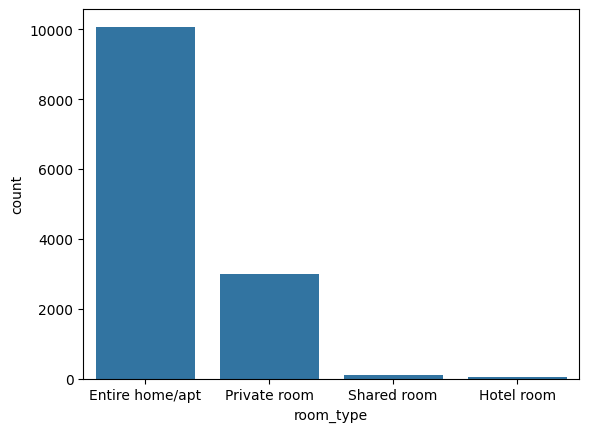

In [36]:
sns.countplot(data=df, x="room_type", order=df["room_type"].value_counts().index)

In [37]:
df["room_type"].value_counts()

room_type
Entire home/apt    10075
Private room        3004
Shared room           97
Hotel room            62
Name: count, dtype: int64

El barplot ya lo deja ver, pero en números: `Entire home/apt` domina con un 76% de los anuncios y `Private room` es un 23%. `Shared room` (0.7%) y `Hotel room` (0.5%) son casi residuales — habrá que tenerlo en cuenta más adelante (p. ej. si se modela por `room_type`, esas dos clases tendrán muy poca muestra).

No se modifica `room_type`: aunque `Shared room` y `Hotel room` tienen muy poca muestra, fusionarlas ahora perdería información real de forma prematura. Se deja anotado para tenerlo en cuenta más adelante (split estratificado, o fusión si algún modelo concreto sufre por la escasez de muestra en esas clases).

## 7. Numéricas

Análisis univariante de las variables numéricas: estadísticos descriptivos y forma de la distribución.

In [38]:
num = df.select_dtypes(include="number").columns
print(num)

Index(['id', 'host_id', 'host_profile_id', 'latitude', 'longitude', 'price',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'number_of_reviews_ltm'],
      dtype='object')


### 7.1 Variables de interés vs. identificadores/geográficas

`id`, `host_id` y `host_profile_id` son identificadores, no variables con una distribución que interese describir. `latitude` y `longitude` son coordenadas geográficas: se analizan en la sección 11 (Análisis geográfico), no aquí como si fueran una magnitud cualquiera. El resto sí son variables numéricas de interés y son las que se describen en esta sección.

In [39]:
num_vars = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
]

### 7.2 Forma de la distribución: asimetría

El `describe()` ya deja intuir colas largas (medias muy por encima de las medianas); se cuantifica con el coeficiente de asimetría.

In [40]:
df[num_vars].skew().sort_values(ascending=False)

number_of_reviews_ltm             14.965771
reviews_per_month                 13.690323
price                              9.007799
number_of_reviews                  4.077367
calculated_host_listings_count     2.239154
minimum_nights                     1.621175
availability_365                  -0.504225
dtype: float64

`number_of_reviews_ltm`, `reviews_per_month`, `price` y `number_of_reviews` tienen una asimetría muy fuerte a la derecha (coeficiente entre 4 y 15): la mayoría de anuncios tiene valores bajos y una minoría se dispara muy por encima, estirando la cola. `calculated_host_listings_count` y `minimum_nights` también son asimétricas, aunque menos. `availability_365` es la única con asimetría negativa (leve): muchos anuncios están disponibles casi todo el año. Esto ya anticipa que habrá que revisar outliers en la sección 8, especialmente en las cuatro primeras.

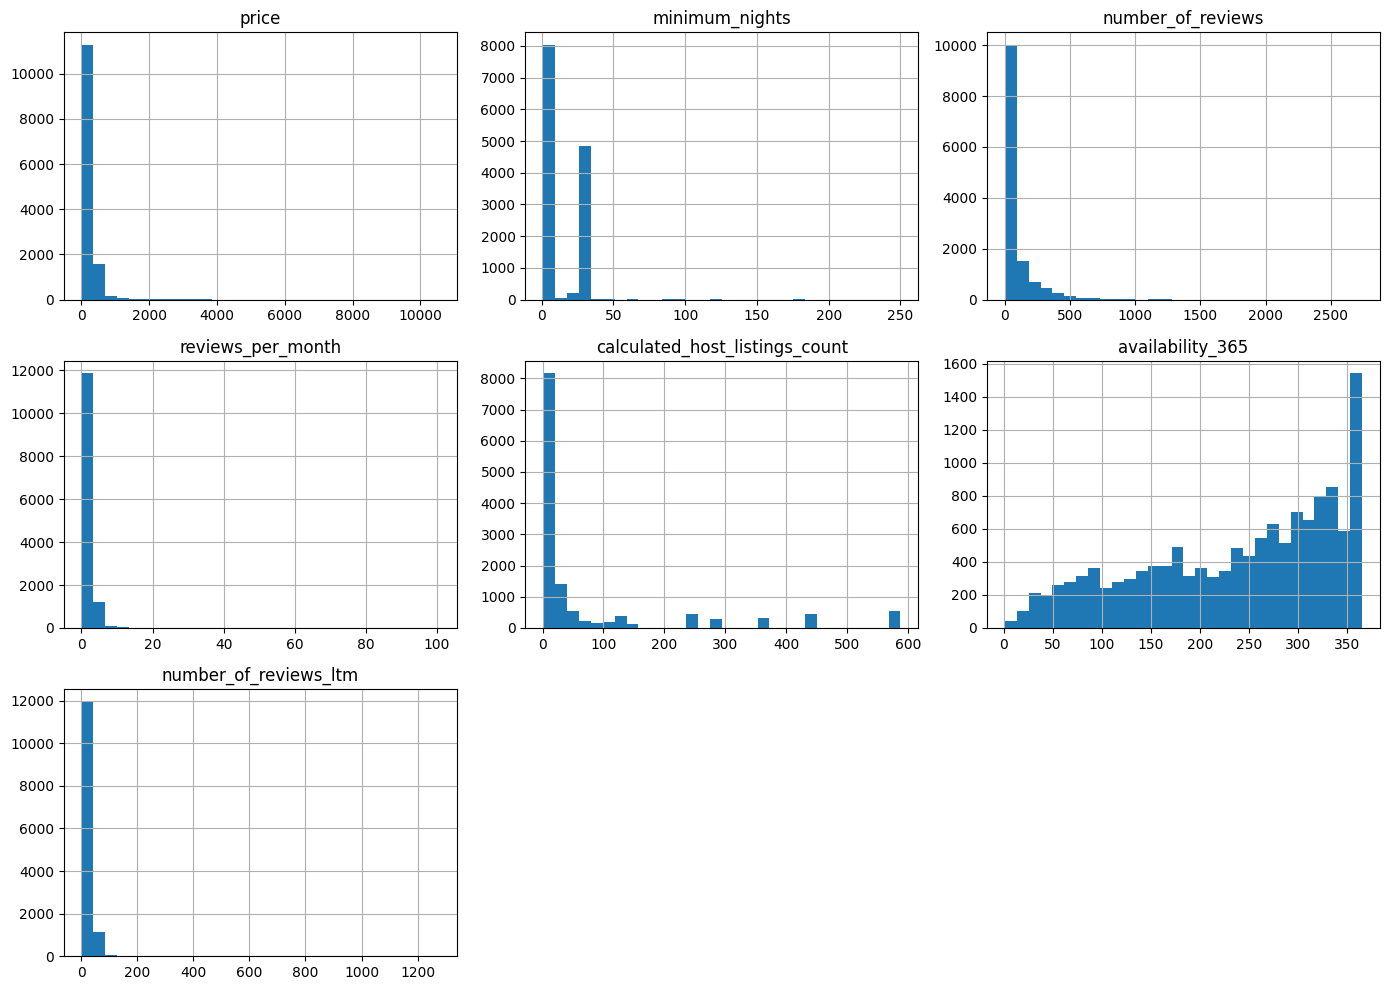

In [41]:
df[num_vars].hist(bins=30, figsize=(14, 10))
plt.tight_layout()

In [42]:
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
price,13238.0,240.987536,340.801295,4.0,89.00,178.0,286.00,10542.00
minimum_nights,13238.0,13.517072,15.745045,1.0,1.00,2.0,31.00,250.00
number_of_reviews,13238.0,73.328146,138.409042,0.0,1.00,11.0,88.00,2740.00
reviews_per_month,13238.0,1.305373,2.199682,0.0,0.05,0.5,2.06,100.58
calculated_host_listings_count,13238.0,79.870147,150.423133,1.0,3.00,12.0,51.00,588.00
availability_365,13238.0,236.934809,99.982968,1.0,158.00,261.0,325.00,365.00
number_of_reviews_ltm,13238.0,14.685904,30.452462,0.0,0.00,3.0,23.00,1276.00


In [43]:
df["price"].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

0.01      24.0
0.25      89.0
0.50     178.0
0.75     286.0
0.99    1815.0
Name: price, dtype: float64

La media de `price` (241€) está muy por encima de la mediana (178€), y el percentil 99 (1815€) es casi 10 veces la mediana — confirma la asimetría detectada arriba y señala que hay anuncios con precios muy extremos que distorsionarán la media si no se tratan (sección 8).

<Axes: xlabel='price', ylabel='Count'>

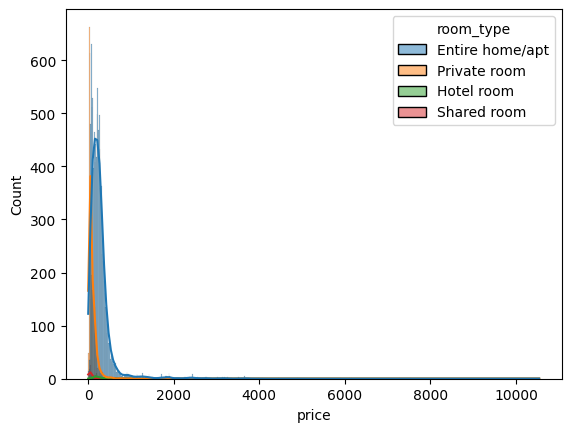

In [44]:
sns.histplot(df, x="price", kde="true", hue="room_type")

<Axes: xlabel='price', ylabel='neighbourhood_group'>

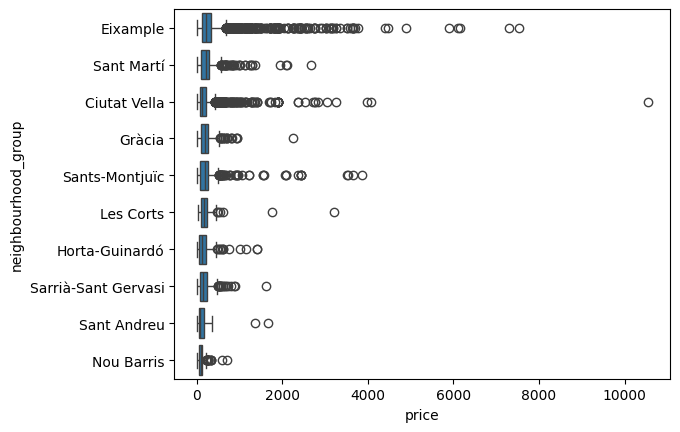

In [45]:
sns.boxplot(x=df["price"], y=df["neighbourhood_group"])

### 7.3 Rangos plausibles

Antes de pasar a outliers estadísticos, se comprueba que no haya valores directamente imposibles: `availability_365` debería estar entre 0 y 365, y `minimum_nights` no debería superar los 365 días.

In [46]:
df["availability_365"].agg(["min", "max"])

min      1
max    365
Name: availability_365, dtype: int64

In [47]:
print("minimum_nights máximo:", df["minimum_nights"].max())
print("filas con minimum_nights > 365:", (df["minimum_nights"] > 365).sum())

minimum_nights máximo: 250.0
filas con minimum_nights > 365: 0


Ambos rangos son coherentes (sin valores imposibles): no hace falta descartar filas por esto, los extremos que haya que tratar en la sección 8 serán estadísticos, no errores evidentes de captura.

## 8. Outliers

Detección y tratamiento de valores extremos que puedan distorsionar el análisis (p. ej. `price` o `minimum_nights`).

### 8.1 Método: rango intercuartílico (IQR)

Se usa la regla estándar del rango intercuartílico sobre `num_vars` (las variables numéricas de interés de la sección 7): un valor se considera outlier si cae por debajo de `Q1 - 1.5·IQR` o por encima de `Q3 + 1.5·IQR`. Se aplica igual a las 7 variables para poder comparar cuántos outliers tiene cada una.

In [48]:
outlier_summary = []
for c in num_vars:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({
        "variable": c,
        "low": low,
        "high": high,
        "n_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_summary

,variable,low,high,n_outliers,pct_outliers
4,calculated_host_listings_count,-69.000,123.000,2441,18.44
2,number_of_reviews,-129.500,218.500,1408,10.64
0,price,-206.500,581.500,585,4.42
6,number_of_reviews_ltm,-34.500,57.500,528,3.99
3,reviews_per_month,-2.965,5.075,410,3.10
1,minimum_nights,-44.000,76.000,34,0.26
5,availability_365,-92.500,575.500,0,0.00


El IQR marca proporciones muy distintas según la variable: `calculated_host_listings_count` (18.4%) y `number_of_reviews` (10.6%) tienen muchísimos puntos por encima del límite superior, mientras que `minimum_nights` (0.26%) y `availability_365` (0%) apenas se ven afectadas. Esto no significa automáticamente que esas variables tengan más "errores": son justo las que ya salieron muy asimétricas en la sección 7.2 (conteos con cola larga, tipo ley de potencias — un host con 200 anuncios o un anuncio con 1000 reviews son reales, no errores de captura). El IQR es una regla pensada para distribuciones más simétricas, así que en estas variables tiende a sobre-marcar como "outlier" lo que en realidad es variabilidad genuina. Se deja como diagnóstico; la decisión de qué hacer con cada una (recortar, transformar con log, o no tocar) se toma variable a variable, no con una regla única.

### 8.2 Visualización

Boxplots de las 7 variables a la vez, para ver de un vistazo dónde se concentran los outliers detectados.

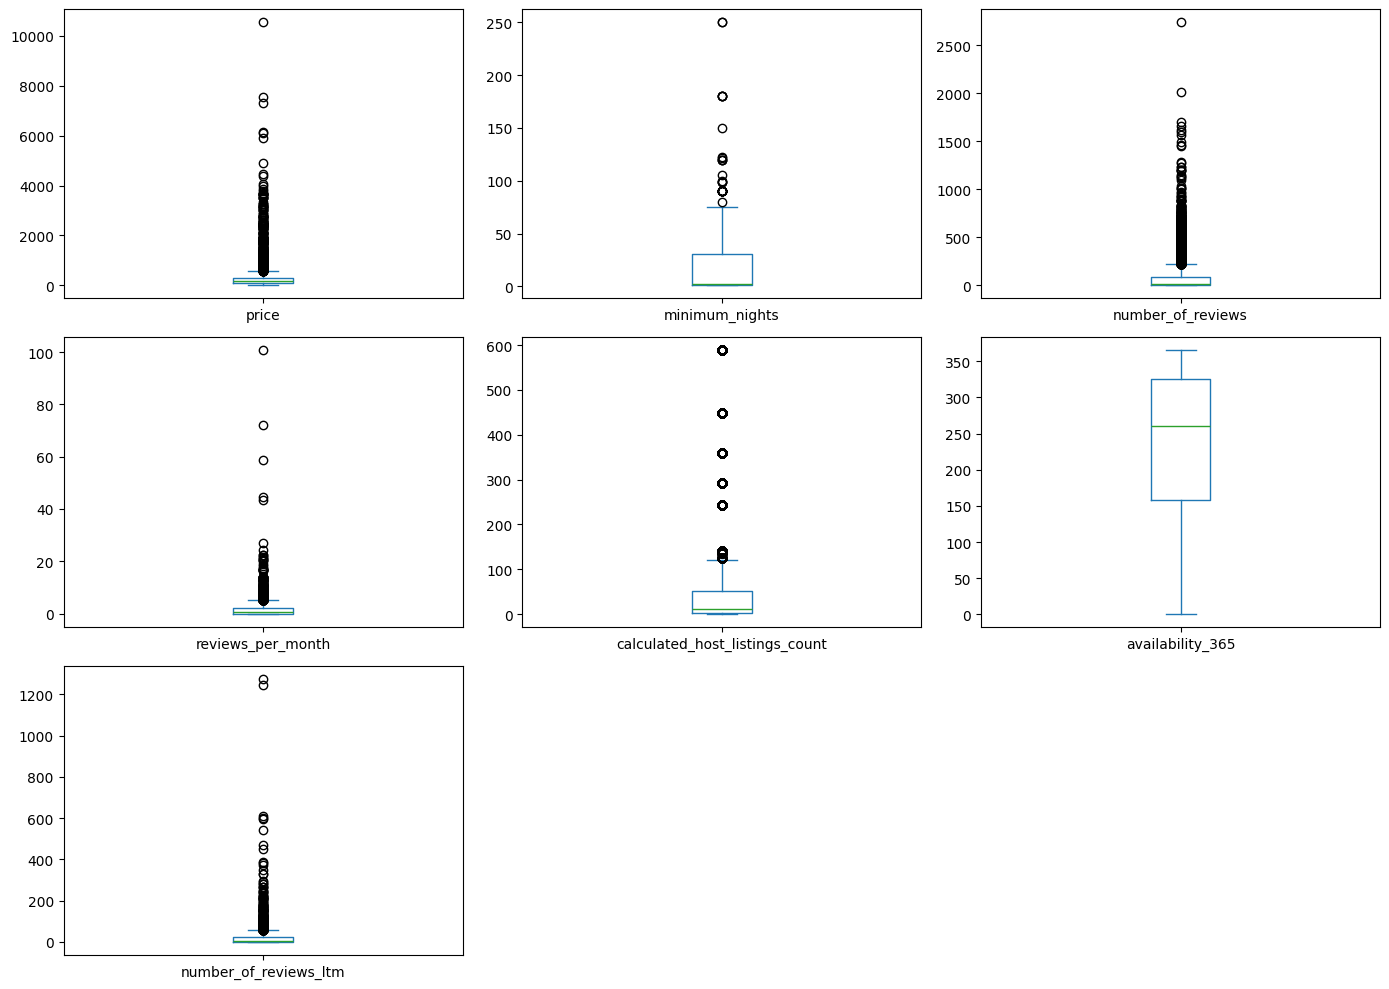

In [49]:
df[num_vars].plot(kind="box", subplots=True, layout=(3, 3), figsize=(14, 10))
plt.tight_layout()

### 8.3 Conclusión y tratamiento

Antes de decidir un recorte genérico por IQR, se revisaron los casos más extremos de cada variable:

- **`price`**: los valores bajos (4-14€) coinciden con `minimum_nights` muy altos (90-250 noches) — son alquileres de larga estancia con descuento por volumen, no errores. Los valores altos son alojamientos de lujo reales.
- **`number_of_reviews_ltm`**: se comprobó que nunca supera a `number_of_reviews` (0 filas inconsistentes) — la asimetría es real, no hay valores imposibles.
- **`reviews_per_month`** alto: coincide siempre con `number_of_reviews` muy alto (listings con miles de reviews acumuladas) — coherente, no anómalo.
- **`calculated_host_listings_count`** alto: corresponde a gestoras profesionales con muchos anuncios — un dato real del negocio, no un error.

**Decisión: no se elimina ni se capa ninguna variable por IQR.** Todo lo marcado como "outlier" en 8.1 es variabilidad real y explicable (colas largas de conteos, estancias largas, hosts profesionales), y forzar un recorte aquí perdería información legítima — sobre todo en `price`, que es la variable económica clave del dataset. Cualquier transformación para modelar (log de `price` y `number_of_reviews`, o un flag de host profesional a partir de `calculated_host_listings_count`) se deja para `02A_fe_listings.ipynb`, donde `price_log` ya se está aplicando.

## 9. Agrupaciones

Análisis bivariante: relación de `price` con otras variables categóricas (barrio, tipo de habitación) mediante agregaciones y gráficos.

In [50]:
df.groupby("neighbourhood_group")["price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

,count,mean,median
neighbourhood_group,,,
Eixample,5158,310.123304,229.5
Sant Martí,1223,224.135732,207.0
Sants-Montjuïc,1276,219.652821,187.0
Gràcia,1192,197.769295,188.0
Les Corts,262,197.694656,162.5
Ciutat Vella,2763,190.985523,114.0
Sarrià-Sant Gervasi,753,175.872510,148.0
Horta-Guinardó,289,168.366782,117.0
Sant Andreu,180,126.644444,79.5


El orden por `mean` y por `median` no coincide: `Ciutat Vella` es 6º por precio medio (191€) pero cae al puesto 8º por precio mediano (114€), mientras que `Sarrià-Sant Gervasi` sube del 7º al 6º. Es justo el efecto de la asimetría que ya vimos en la sección 8: unos pocos anuncios de precio muy alto en el centro histórico (turístico/lujo) inflan la media sin representar el alojamiento típico de la zona. Conclusión: para comparar barrios por precio conviene mirar la mediana (o ambas), no solo la media.

In [51]:
df.groupby(["neighbourhood_group", "neighbourhood"])["price"].sum().sort_values(ascending=False)

neighbourhood_group  neighbourhood                  
Eixample             la Dreta de l'Eixample             681308.0
                     Sant Antoni                        233740.0
                     la Sagrada Família                 214704.0
                     la Nova Esquerra de l'Eixample     190882.0
                     l'Antiga Esquerra de l'Eixample    185491.0
                                                          ...   
Nou Barris           la Trinitat Nova                      196.0
Horta-Guinardó       Montbau                               120.0
Sant Andreu          la Trinitat Vella                      88.0
Nou Barris           Ciutat Meridiana                       80.0
                     Torre Baró                             57.0
Name: price, Length: 69, dtype: float64

El precio total (`sum`) por barrio mezcla precio con volumen de anuncios, así que no dice cuáles son realmente los barrios más caros. Para eso se usa la mediana por barrio (más robusta que la media dado el sesgo de `price`), filtrando los barrios con menos de 10 anuncios — igual que en la sección 6 — para que la mediana no la dominen 2-3 anuncios sueltos.

<Axes: xlabel='median', ylabel='neighbourhood'>

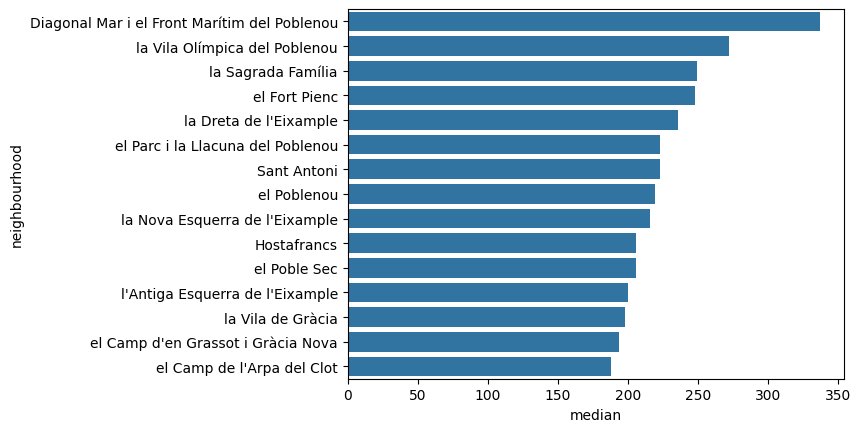

In [52]:
neighbourhood_price = df.groupby("neighbourhood")["price"].agg(["count", "median"])
neighbourhood_price = neighbourhood_price[neighbourhood_price["count"] >= 10]
top15_expensive = neighbourhood_price.sort_values("median", ascending=False).head(15)

sns.barplot(x=top15_expensive["median"], y=top15_expensive.index)

<Axes: xlabel='room_type', ylabel='price'>

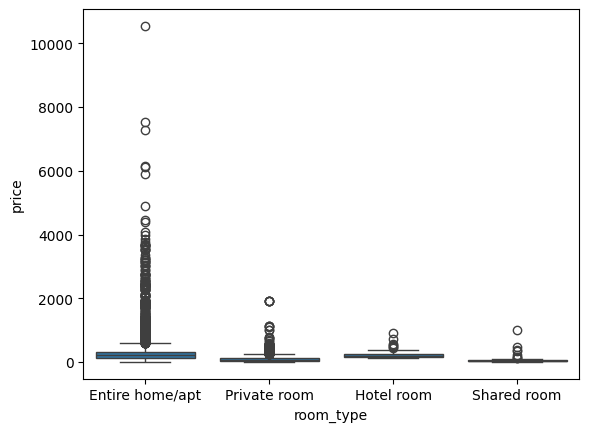

In [53]:
sns.boxplot(data=df, x="room_type", y="price")

In [54]:
df.groupby("room_type")["price"].agg(["count", "mean", "median"])

,count,mean,median
room_type,,,
Entire home/apt,10075,285.302035,222.0
Hotel room,62,252.532258,196.0
Private room,3004,97.516977,62.0
Shared room,97,73.989691,46.0


El boxplot por `room_type` es difícil de leer: `Entire home/apt` llega hasta 10542€ (el máximo de todo el dataset), así que el eje se estira y las cajas quedan aplastadas abajo. No se recorta el dato (sección 8 ya decidió no tocar `price`), pero para verlo mejor se repite el gráfico ocultando los valores atípicos (`showfliers=False`) — es solo un cambio de visualización, no de los datos.

<Axes: xlabel='room_type', ylabel='price'>

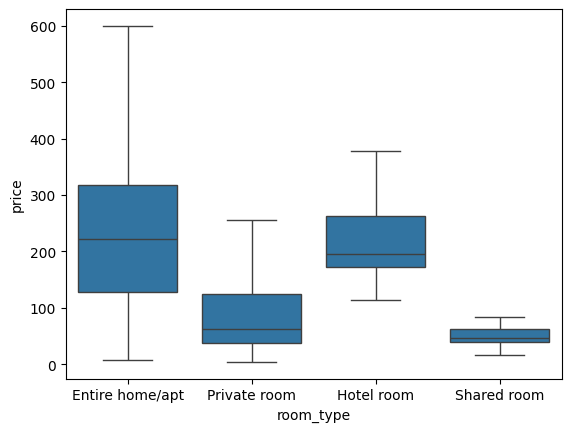

In [55]:
sns.boxplot(data=df, x="room_type", y="price", showfliers=False)

En conjunto, ambas variables categóricas explican parte del precio: `neighbourhood_group` marca una diferencia clara entre distritos (aunque hay que mirar la mediana, no solo la media) y `room_type` separa con nitidez `Entire home/apt`/`Hotel room` (más caros) de `Private room`/`Shared room` (más baratos). Se analizará su efecto conjunto y el resto de variables numéricas en la sección 10 (Correlación).

## 10. Correlación y visualización

Análisis multivariante: correlaciones entre variables numéricas y su relación conjunta con `price`.

### 10.1 Correlación con `price`

Igual que en la sección 7.1, se excluyen `id`, `host_id`, `host_profile_id` (identificadores) y `latitude`/`longitude` (se tratan en la sección 11): no aportan nada como correlación y solo ensucian la tabla/heatmap con relaciones espurias (p. ej. `host_id` y `host_profile_id` correlacionan entre sí solo por cómo se asignan los IDs, no por nada real). Se usa `num_vars` más `has_license`.

In [56]:
corr_vars = num_vars + ["has_license"]
df[corr_vars].corr()["price"].sort_values(ascending=False)

price                             1.000000
calculated_host_listings_count    0.217195
has_license                       0.154624
availability_365                  0.097630
number_of_reviews                 0.051859
number_of_reviews_ltm             0.041977
reviews_per_month                 0.029002
minimum_nights                   -0.329020
Name: price, dtype: float64

La correlación de Pearson asume una relación lineal, pero en las secciones 7 y 8 ya vimos que varias de estas variables tienen colas muy largas (asimetría de hasta 15). Se compara con Spearman (basada en rangos, capta relaciones monótonas aunque no sean lineales) para ver si el diagnóstico cambia.

In [57]:
df[corr_vars].corr(method="spearman")["price"].sort_values(ascending=False)

price                             1.000000
number_of_reviews                 0.430043
number_of_reviews_ltm             0.428615
reviews_per_month                 0.401735
has_license                       0.353090
calculated_host_listings_count    0.107066
availability_365                  0.026694
minimum_nights                   -0.648216
Name: price, dtype: float64

El cambio es muy grande para varias variables: `number_of_reviews` pasa de 0.05 (Pearson, prácticamente nula) a 0.43 (Spearman, moderada), `number_of_reviews_ltm` de 0.04 a 0.43, `reviews_per_month` de 0.03 a 0.40, y `has_license` de 0.15 a 0.35. `minimum_nights` pasa de -0.33 a -0.65, una relación bastante más fuerte de lo que sugería Pearson. En cambio `calculated_host_listings_count` baja de 0.22 a 0.11.

Conclusión: mirar solo la correlación de Pearson da una imagen engañosa aquí — variables de reviews que parecían casi irrelevantes para `price` en realidad sí tienen una relación monótona real, solo que no lineal (el sesgo la esconde). Para seleccionar variables de cara a un modelo conviene mirar ambas, no solo Pearson.

*(El barplot de `price` por `neighbourhood_group` que había aquí se elimina: es la misma información que ya se analizó con más detalle en la sección 9, con tabla de mean/median y boxplot.)*

### 10.2 Heatmap

Mismo criterio: solo las variables relevantes, con Spearman (más representativa dado el sesgo) y con los valores anotados para poder leerlos directamente en vez de solo por color.

<Axes: >

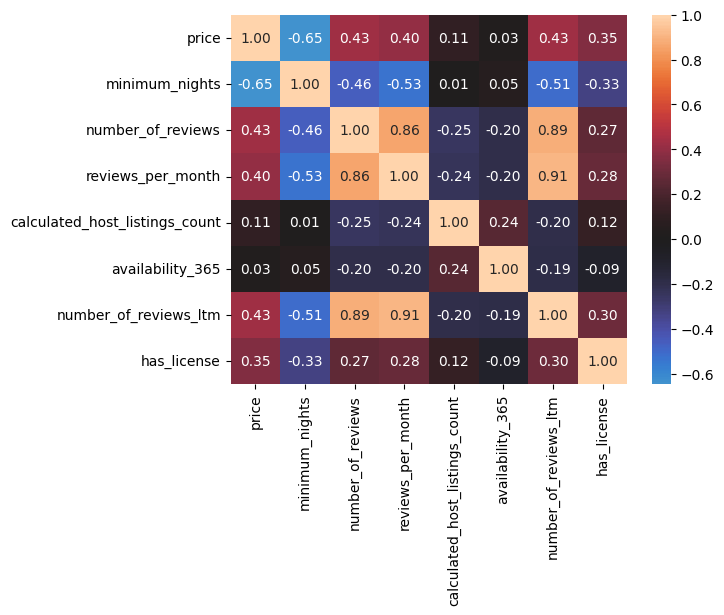

In [58]:
sns.heatmap(
    df[corr_vars].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    center=0,
)

### 10.3 Pairplot

El pairplot con `price`, `minimum_nights` y `number_of_reviews` en su escala original no se puede leer: la asimetría de las tres hace que casi todos los puntos se amontonen en una esquina y los ejes se estiren por un puñado de valores extremos. Se aplica `log1p` solo para esta visualización (no se toca `df`, igual que el boxplot sin fliers de la sección 9) para poder ver la estructura real.

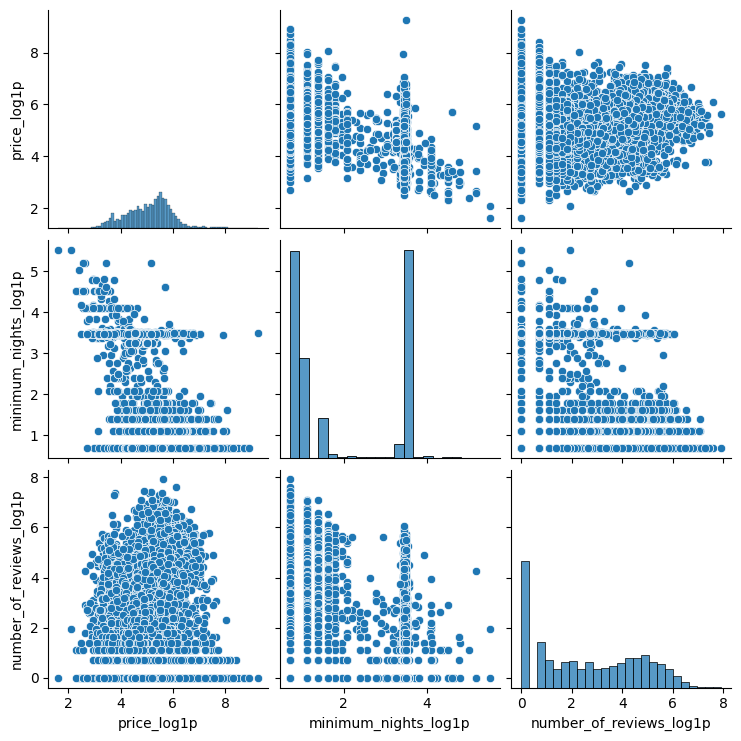

In [59]:
# Solo para visualizar: log1p aplicado de forma temporal, no se modifica df (igual criterio que el boxplot sin fliers de la sección 9)
pairplot_data = np.log1p(df[["price", "minimum_nights", "number_of_reviews"]]).add_suffix("_log1p")
sns.pairplot(pairplot_data)

En conjunto, la sección 10 confirma que `price` tiene relación con varias variables (sobre todo reviews y `minimum_nights`), pero que hay que mirarla con Spearman y no solo con Pearson dado el sesgo ya documentado en las secciones 7 y 8. Esto es información útil de cara al modelado en los siguientes notebooks, no un tratamiento que se aplique aquí.

## 11. Análisis geográfico

Visualización espacial de los anuncios (latitud/longitud) para detectar patrones de precio o densidad por zona.

### 11.1 Rango de coordenadas

Antes de graficar, se comprueba que `latitude`/`longitude` caen dentro de Barcelona y no hay coordenadas sueltas fuera de rango (p. ej. por un error de captura tipo 0,0).

In [60]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,41.351783,2.092414
max,41.462243,2.221390


El rango es coherente con Barcelona (latitud ~41.35-41.46, longitud ~2.09-2.22): no hay coordenadas fuera de lugar.

### 11.2 Distribución espacial por distrito

Se pinta cada anuncio en su coordenada real, coloreado por `neighbourhood_group`. Además de ver la densidad, sirve como comprobación cruzada: si el barrio asignado a cada fila fuera incorrecto, se notaría como colores mezclados sin ninguna forma reconocible.

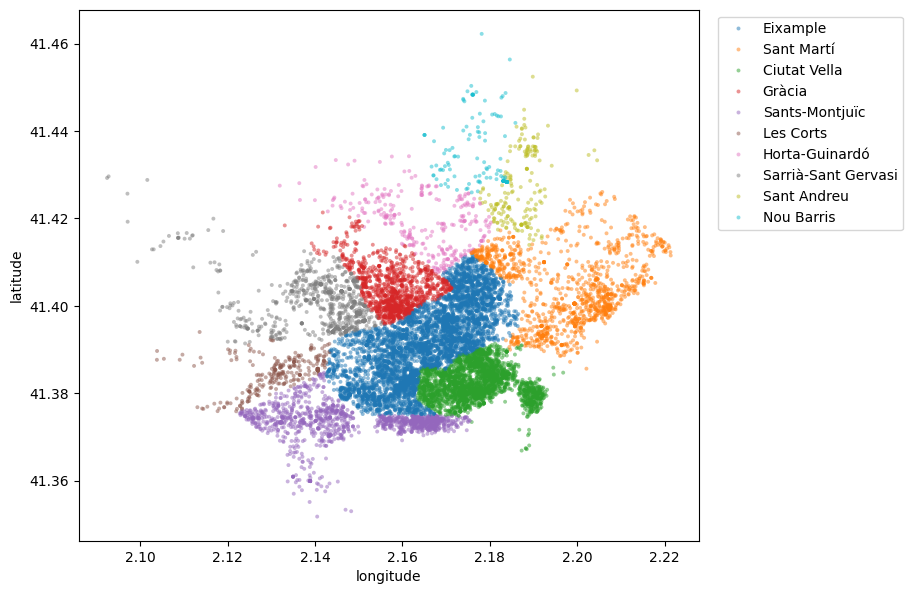

In [61]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="neighbourhood_group",
    s=8, alpha=0.5, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

Los distritos forman regiones geográficas compactas y sin apenas solape — coincide con la forma real de Barcelona (p. ej. `Ciutat Vella` pegado a la costa, `Sarrià-Sant Gervasi` en la zona alta). Confirma que `neighbourhood_group` está bien asignado, no es ruido.

### 11.3 Precio en el mapa

Mismo mapa, coloreado ahora por `price` (en `log1p`, por la asimetría ya vista en las secciones 7-8), para ver si el patrón espacial de precio coincide con lo encontrado en la sección 9 (Eixample y el centro histórico más caros).

Text(0, 0.5, 'latitude')

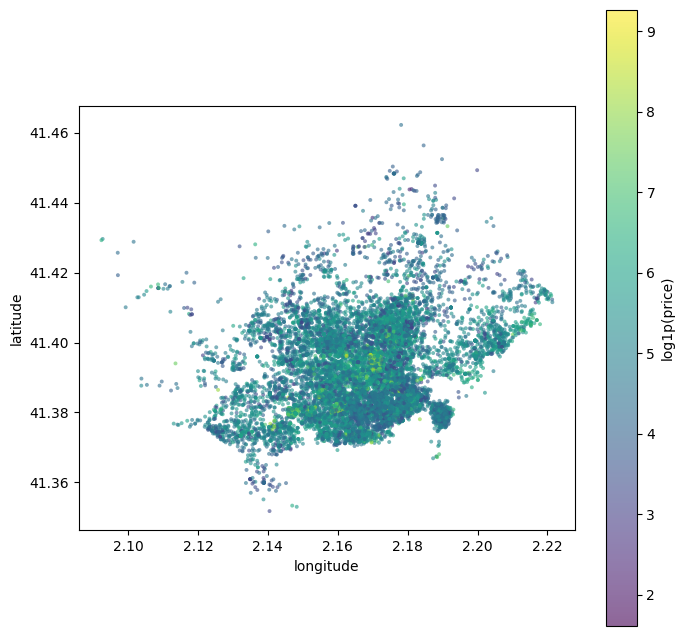

In [62]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=np.log1p(df["price"]), cmap="viridis",
    s=8, alpha=0.6, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")

Se intuyen tonos más claros (precio más alto) en la zona central y hacia el mar, coherente con el `Eixample`/centro histórico que ya salían como los más caros en la sección 9 — aunque con el `alpha` bajo y tantos puntos solapados, el patrón es sutil más que contundente. Confirma la señal, no aporta mucho más de lo que ya sabíamos por la tabla de la sección 9.

## 12. Conclusiones

Resumen de los principales hallazgos del EDA.

### Limpieza aplicada

De las 15406 filas originales quedan **13238** tras:
- Nulos: `reviews_per_month` imputado a 0 y `last_review` dejado como `NaT` para anuncios sin reviews; `license` imputado a `"Sin licencia"`; filas sin `price` descartadas (variable clave, no se imputa); filas con nulos de bajo volumen en columnas de host/`minimum_nights` descartadas (15406 → 13276).
- Duplicados: sin duplicados de fila completa ni de `id`. De 222 filas "duplicados lógicos" (mismo edificio/host), 38 eran copias exactas salvo `id` y se eliminaron; el resto son anuncios reales distintos con licencia e historial propios (13276 → 13238).

### Variables nuevas

- `has_license`: flag booleano a partir de `license` (13.4% sin licencia).
- `neighbourhood_grouped`: `neighbourhood` con los 12 barrios de menos de 10 anuncios agrupados en `"Otros"`.

### Principales hallazgos sobre `price`

- Muy asimétrico (skew ≈ 9, mediana 178€ vs. p99 1815€), con extremos que son alojamientos de lujo o alquileres de larga estancia reales, no errores — no se ha recortado nada.
- El barrio importa, pero la media engaña: `Ciutat Vella` parece caro por media pero baja mucho por mediana (unos pocos anuncios de lujo la inflan). Mejor comparar por mediana.
- `room_type` separa bien: `Entire home/apt`/`Hotel room` son claramente más caros que `Private room`/`Shared room`.
- Pearson infravalora la relación de `price` con las variables de reviews (`number_of_reviews`, `reviews_per_month`, `number_of_reviews_ltm`) y con `minimum_nights`: con Spearman la correlación es mucho más fuerte, porque la relación es monótona pero no lineal.
- El patrón espacial de precio (centro más caro) es coherente con lo anterior, y las coordenadas confirman que `neighbourhood_group` está bien asignado.

### De cara al modelado (decisiones diferidas, no aplicadas aquí)

- `name` y `host_name`: cuasi-identificadores de texto libre; posible señal de texto o un flag `is_professional_host` a partir de `calculated_host_listings_count`, en `02A_fe_listings.ipynb`.
- `price`, `number_of_reviews` y similares: candidatos a log-transform (`price_log` ya se usa en `02A_fe_listings.ipynb`) en vez de recortar outliers.
- `room_type`: mantener las 4 clases pese al desbalance (`Shared room`/`Hotel room` con poca muestra); usar split estratificado.

## 13. Exportar dataset limpio

Guardar el dataset resultante tras la limpieza en `data/processed/` para su uso en los siguientes notebooks (feature engineering).

In [63]:
df.to_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_clean.csv", index=False)